# Feature Engineering for Accurate Classification of User Stories with AI-Driven Functionalities

In agile software development, user story classification that implements Artificial Intelligence (AI) helps support automatic backlog refinement, strategic planning, effort estimation, and skill requirements within the team. This study employs Logistic Regression (LGR) and Support Vector Machine (SVM) models to assess the influence of lexical, static, and contextualized features on classification performance. The proposed feature engineering approach incorporates text representations generated by TF-IDF, BM25, SPLADE, Word2Vec and BERT to classify AI-driven functionalities. Using the metrics of Accuracy (ACC) and F1-score (F1) the results show that combining frequency-based representations from TF-IDF and embeddings from BERT-based variants yields better performance. By achieving an accuracy of 75.89% accuracy and 75.18% F1-score with the SVM + TF-IDF + MPNet + MiniLM (subsampled) configuration. Similarly, the SVC + TF-IDF + MPNet + MiniLM model obtained 76.79% accuracy and 74.90% F1-macro, showing a balanced classification performance across both classes. When compared with the baseline TF-IDF models, which achieved approximately 74–75% accuracy, the proposed hybrid representations improved the results by about 2 percentage points in accuracy. These findings highlight the effectiveness of combining engineered lexical features with contextual sentence embeddings, providing empirical evidence that hybrid textual representations improve the classification of AI-driven user stories.

# ⓿ Packages

In [ ]:
!pip install gensim nltk --quiet
!pip show numpy pandas scikit-learn --quiet
!pip show imbalanced-learn --quiet
!pip install rank-bm25 --quiet
!python -m spacy download en_core_web_md
# !pip install fastembed  --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 8.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import time
import random
import numpy as np
import pandas as pd

from typing import List, Optional, Union

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import brier_score_loss

# Sampling (Imbalanced-learn)
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, SVMSMOTE
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.metrics import specificity_score
from rank_bm25 import BM25Okapi

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC, SVC, OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import RidgeClassifier

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import normalize, Normalizer
from scipy.sparse import hstack, vstack, csr_matrix

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, log_loss)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sentence_transformers import SentenceTransformer

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


import spacy

In [ ]:
random_state = 42
np.random.seed(random_state)
random.seed(random_state)
figsize=(10, 10)
fontsize=24

# ① Load dataset

In [ ]:
df = pd.read_csv('./hus.csv', sep=";", header=None, names=['ID','user_story','Label','1','2'])
df = df.drop(columns=['1', '2'])
df.head(3)

,ID,user_story,Label
0,HU1,"As a Data user, I want to have the 12-19-2017 ...",0
1,HU2,"As a UI designer, I want to redesign the Resou...",1
2,HU3,"As a UI designer, I want to report to the Agen...",1


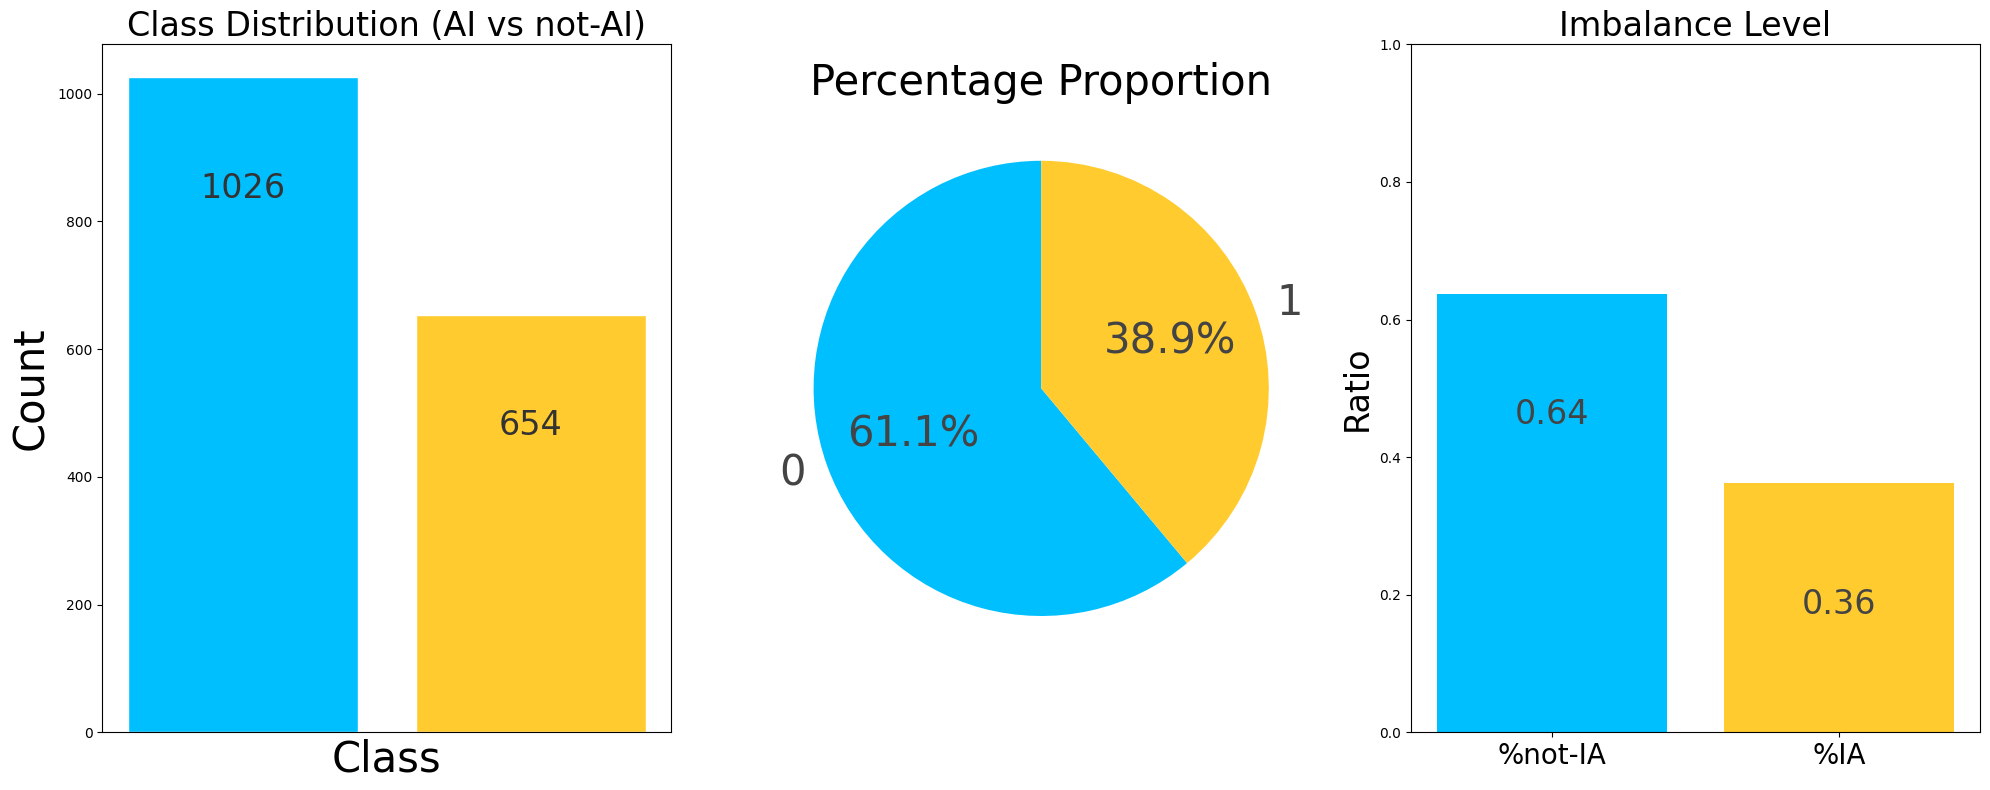

In [ ]:
# Assuming that 1-'AI' and 0-'not-AI' are the classes
classes = df['Label'].value_counts()

plt.figure(figsize=(20, 8))

# Subplot 1: Simple bar chart
plt.subplot(1, 3, 1)
bars = plt.bar(classes.index, classes.values, color=['#00BFFF', '#FFCB2E'], edgecolor='white')
plt.title('Class Distribution (AI vs not-AI)',fontsize=24)
plt.xlabel('Class',fontsize=30)
plt.ylabel('Count',fontsize=30)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height - 200, f'{int(height)}', ha='center', va='bottom', fontsize=24, color='#333')
plt.xticks([])

# Subplot 2: Pie chart
plt.subplot(1, 3, 2)
plt.pie(classes.values, labels=classes.index, autopct='%2.1f%%',
        colors=['#00BFFF', '#FFCB2E'], startangle=90,textprops={'fontsize': 30, 'color':'#444'})
plt.title('Percentage Proportion',fontsize=30)

# Subplot 3: Imbalance analysis
plt.subplot(1, 3, 3)
balance_ratio = classes.min() / classes.max()
imbalance_level = [balance_ratio, 1 - balance_ratio]
labels = ['%not-IA', '%IA']
colors_balance = ['#00BFFF', '#FFCB2E']

plt.bar(labels, imbalance_level, color=colors_balance)
plt.ylim(0, 1)
plt.xticks(fontsize=20)
plt.title('Imbalance Level',fontsize=24)
plt.ylabel('Ratio',fontsize=24)

for i, v in enumerate(imbalance_level):
    plt.text(i, v - 0.2, f'{v:.2f}', ha='center', va='bottom', fontsize=24, color='#444')

plt.tight_layout()
plt.show()

In [ ]:
# Análisis detallado
print("🔍 ANÁLISIS DETALLADO:")
print(f"Clase mayoritaria: {classes.idxmax()} ({classes.max()} instancias)")
print(f"Clase minoritaria: {classes.idxmin()} ({classes.min()} instancias)")
print(f"Ratio de desbalance: {classes.max()/classes.min():.2f}:1")
print(f"Porcentaje clase minoritaria: {(classes.min()/len(df))*100:.1f}%")

🔍 ANÁLISIS DETALLADO:
Clase mayoritaria: 0 (1026 instancias)
Clase minoritaria: 1 (654 instancias)
Ratio de desbalance: 1.57:1
Porcentaje clase minoritaria: 38.9%


# ② Train/Test Split

In [ ]:
df_balanced = df
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced, df_balanced['Label'],
    test_size=0.20,
    stratify=df_balanced['Label'], # Ensure that each class has the same number of samples [Gaona et al 2024]
    random_state=random_state
)
print(f"Training set class distribution: {Counter(y_train)}")
print(f"{y_train.value_counts(normalize=True)[0]*100:.2f} No-IA, % {y_train.value_counts(normalize=True)[1]*100:.2f} IA in training set")
print(f"Test set class distribution: {Counter(y_test)}")
print(f"{y_test.value_counts(normalize=True)[0]*100:.2f} No-IA, % {y_test.value_counts(normalize=True)[1]*100:.2f} IA in test set")

Training set class distribution: Counter({0: 821, 1: 523})
61.09 No-IA, % 38.91 IA in training set
Test set class distribution: Counter({0: 205, 1: 131})
61.01 No-IA, % 38.99 IA in test set


In [ ]:
# Undersampling strategy
# Downsample majority to match minority
X_train_ai = X_train[X_train['Label'] == 1]
X_train_not_ai = X_train[X_train['Label'] == 0].sample(n=len(X_train_ai), random_state=random_state)
X_resampled_pruning = pd.concat([X_train_ai, X_train_not_ai])
y_resampled_pruning = X_resampled_pruning['Label']
# X_resampled_pruning = X_resampled_pruning.drop('Label', axis=1)

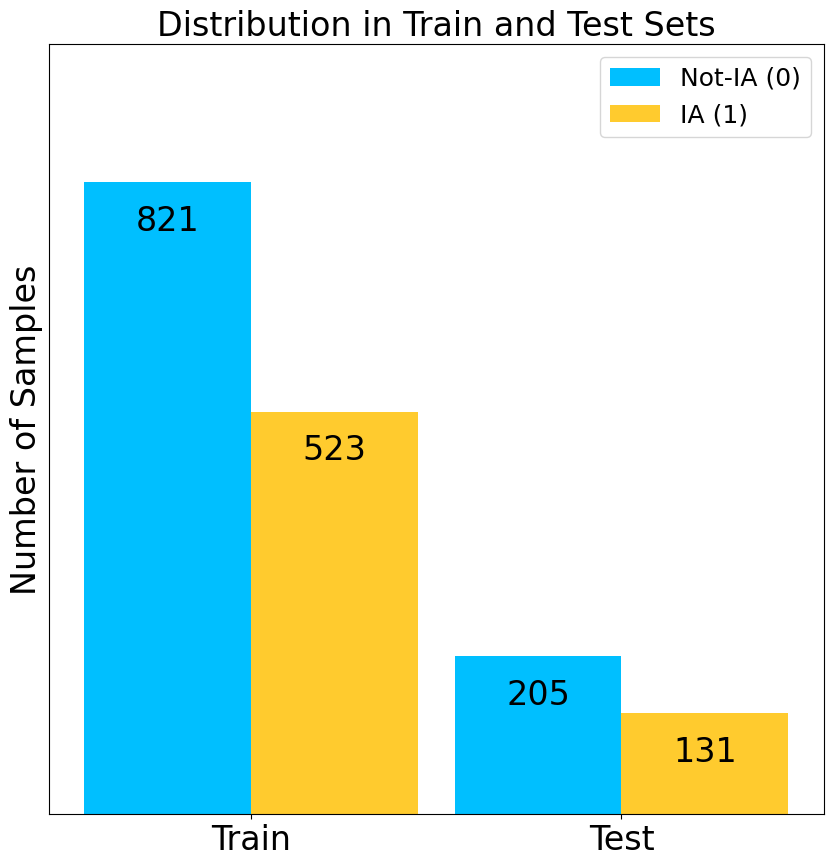

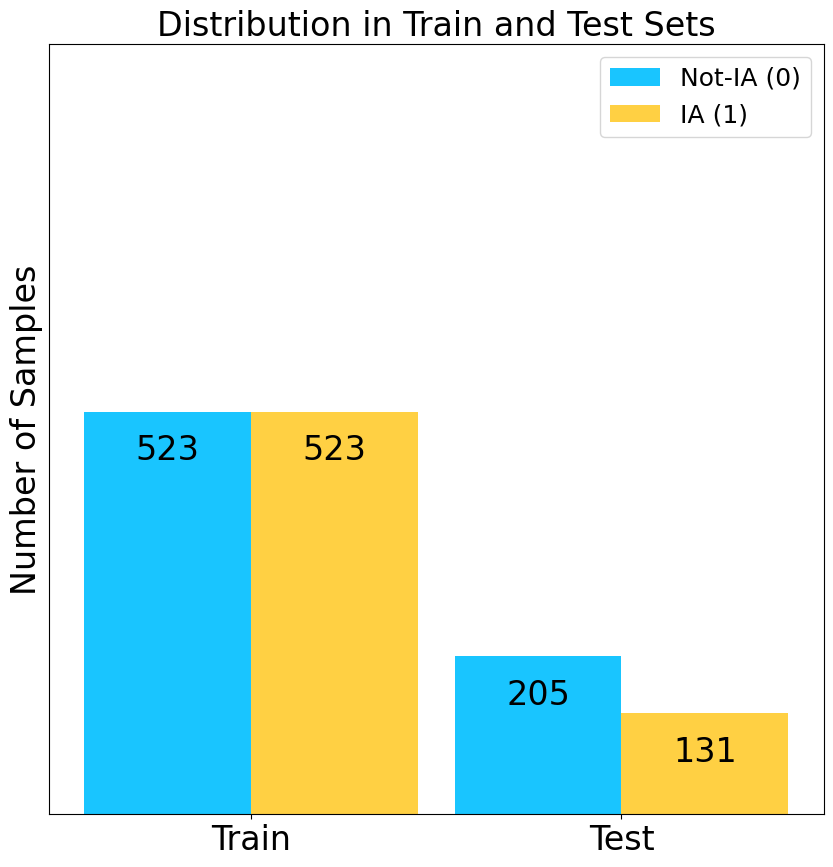

In [ ]:
# Count samples per class
classes = np.unique(y_train)
train_counts = [len(X_train[X_train['Label'] == 0]), len(X_test[X_test['Label'] == 0])]
test_counts = [len(X_train[X_train['Label'] == 1]), len(X_test[X_test['Label'] == 1])]

x = np.arange(len(classes))  # label locations
width = 0.45  # bar width

plt.figure(figsize=figsize)
bar_container = plt.bar(x - width/2, train_counts, width, label='Not-IA (0)', color='#00BFFF')
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

bar_container= plt.bar(x + width/2, test_counts, width, label='IA (1)', color="#FFCB2E")
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

plt.ylim(top=1000)

# plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples', fontsize=fontsize)
plt.title('Distribution in Train and Test Sets', fontsize=fontsize)
plt.xticks(x, ['Train', 'Test'], fontsize=fontsize)
plt.yticks([])
plt.legend(fontsize=fontsize-6)
plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.show()

# Count samples per class
classes = np.unique(y_resampled_pruning)
train_counts = [len(X_resampled_pruning[X_resampled_pruning['Label'] == 0]), len(X_test[X_test['Label'] == 0])]
test_counts = [len(X_resampled_pruning[X_resampled_pruning['Label'] == 1]), len(X_test[X_test['Label'] == 1])]


plt.figure(figsize=figsize)
bar_container = plt.bar(x - width/2, train_counts, width, label='Not-IA (0)', color='#00BFFF', alpha=0.9)
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

bar_container= plt.bar(x + width/2, test_counts, width, label='IA (1)', color="#FFCB2E", alpha=0.9)
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

plt.ylim(top=1000)

# plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples', fontsize=fontsize)
plt.title('Distribution in Train and Test Sets', fontsize=fontsize)
plt.xticks(x, ['Train', 'Test'], fontsize=fontsize)
plt.yticks([])
plt.legend(fontsize=fontsize-6)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

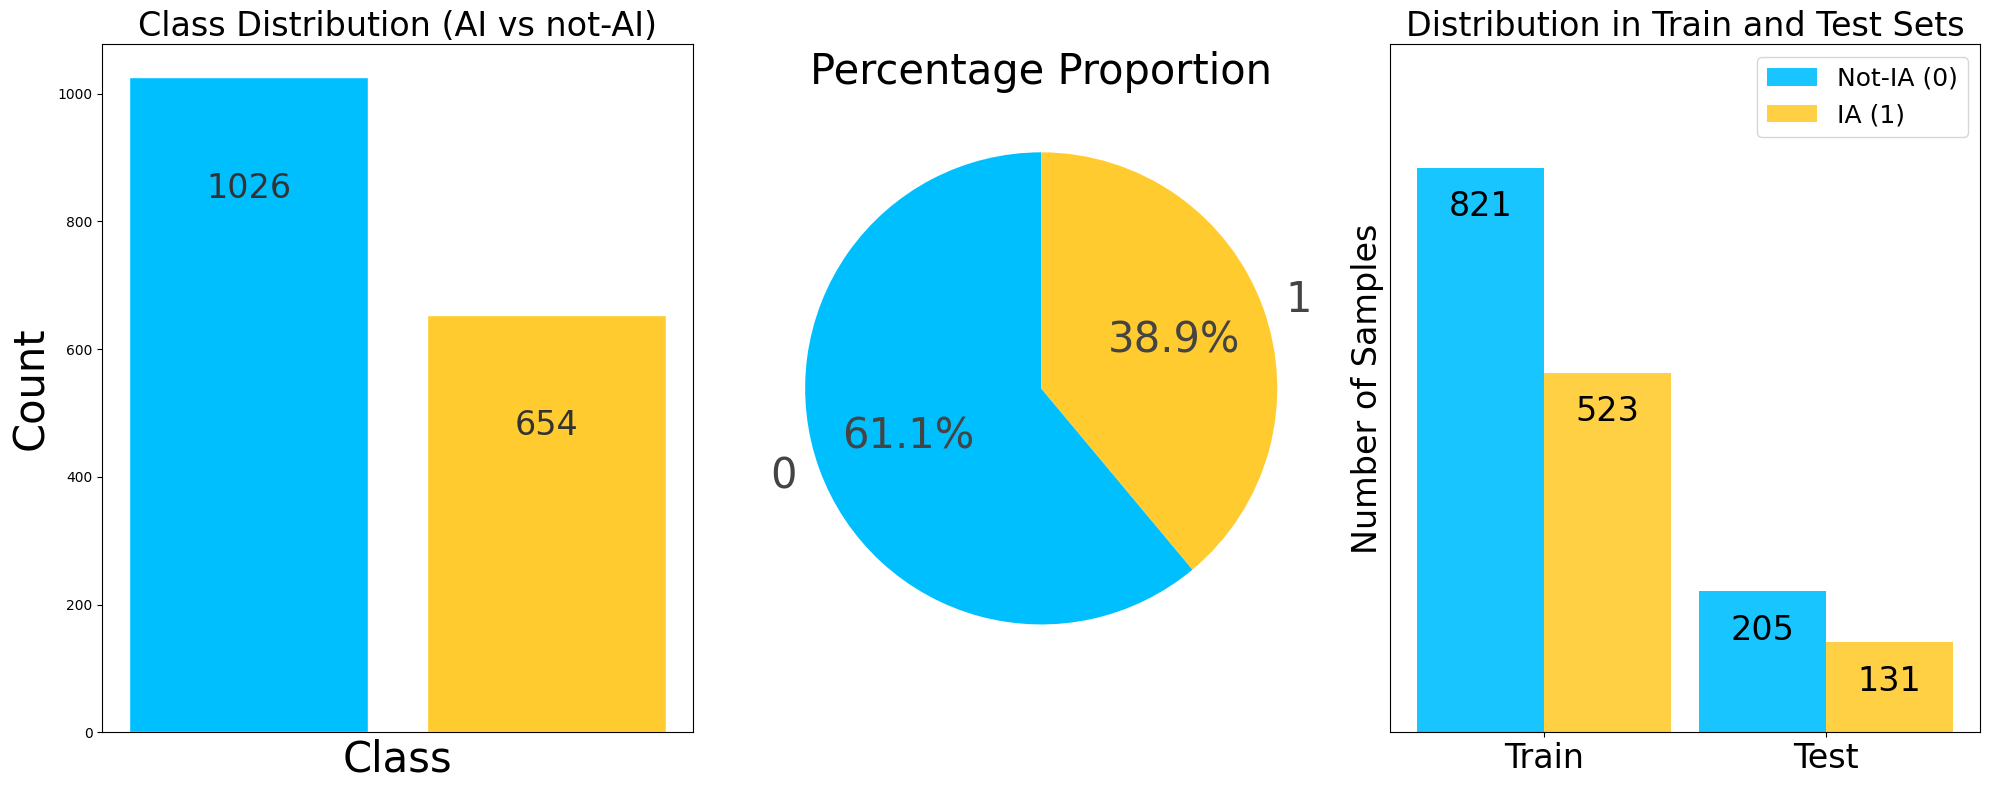

In [ ]:
# Assuming that 1-'AI' and 0-'not-AI' are the classes
classes = df['Label'].value_counts()

plt.figure(figsize=(20, 8))

# Subplot 1: Simple bar chart
plt.subplot(1, 3, 1)
bars = plt.bar(classes.index, classes.values, color=['#00BFFF', '#FFCB2E'], edgecolor='white')
plt.title('Class Distribution (AI vs not-AI)',fontsize=24)
plt.xlabel('Class',fontsize=30)
plt.ylabel('Count',fontsize=30)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height - 200, f'{int(height)}', ha='center', va='bottom', fontsize=24, color='#333')
plt.xticks([])

# Subplot 2: Pie chart
plt.subplot(1, 3, 2)
plt.pie(classes.values, labels=classes.index, autopct='%2.1f%%',
        colors=['#00BFFF', '#FFCB2E'], startangle=90,textprops={'fontsize': 30, 'color':'#444'})
plt.title('Percentage Proportion',fontsize=30)

# Subplot 3: Imbalance analysis
classes = np.unique(y_train)
train_counts = [len(X_train[X_train['Label'] == 0]), len(X_test[X_test['Label'] == 0])]
test_counts = [len(X_train[X_train['Label'] == 1]), len(X_test[X_test['Label'] == 1])]

plt.subplot(1, 3, 3)
bar_container = plt.bar(x - width/2, train_counts, width, label='Not-IA (0)', color='#00BFFF', alpha=0.9)
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

bar_container= plt.bar(x + width/2, test_counts, width, label='IA (1)', color="#FFCB2E", alpha=0.9)
plt.bar_label(bar_container, padding=-40, fontsize=fontsize, color='#000')

plt.ylim(top=1000)

# plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples', fontsize=fontsize)
plt.title('Distribution in Train and Test Sets', fontsize=fontsize)
plt.xticks(x, ['Train', 'Test'], fontsize=fontsize)
plt.yticks([])
plt.legend(fontsize=fontsize-6)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# for i, v in enumerate(imbalance_level):
#     plt.text(i, v - 0.2, f'{v:.2f}', ha='center', va='bottom', fontsize=24, color='#444')

plt.tight_layout()
plt.show()

# ③ Auxiliar Functions

In [ ]:
def train_test_model(
    models: dict,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name=None,
    sort_by: Optional[List[str]] = None,
    ascending: Optional[List[bool]] = None,
    random_state: Optional[int] = 42,
    verbose: bool = False,
):
    if sort_by is None:
        sort_by = ["Accuracy", "F1_macro"]

    if ascending is None:
        ascending = [False] * len(sort_by)

    if models is None:
        models = {
            "DMC": DummyClassifier(strategy="stratified", random_state=random_state)
        }
    results = []

    # ---------------- Evaluation Loop ----------------
    for idx, (name, model) in enumerate(models.items(), start=1):

        X_train = X_train.toarray() if hasattr(X_train, "toarray") else X_train
        X_test = X_test.toarray() if hasattr(X_test, "toarray") else X_test

        if verbose: print(f"Training {name}...")
        start = time.perf_counter()

        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start

        start = time.perf_counter()
        y_pred = model.predict(X_test)
        predict_time = time.perf_counter() - start

        qty_decimals = 4

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:,1]
            y_pred = (probs > 0.6).astype(int)

        # Compute per-class metrics
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
        classes = sorted(set(y_test))
        metrics = {
            "id": idx,
            "Model": f"{name} + {model_name}" if model_name else name,

            # Overall metrics
            "Accuracy": round(accuracy_score(y_test, y_pred), qty_decimals),
            "F1_macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), qty_decimals),
            "MCC": round(matthews_corrcoef(y_test, y_pred), qty_decimals),
        }

        # Probabilities if available
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            y_test_bin = label_binarize(y_test, classes=classes)

            metrics["ROC_AUC"] = roc_auc_score(y_test_bin, y_proba[:, 1], average="macro", multi_class="ovr")
            # metrics["Log_Loss"] = log_loss(y_test_bin, y_proba[:, 1])
            # metrics["Brier_Loss"] = round(brier_score_loss(y_test_bin, y_proba[:, 1]), qty_decimals)

        else:
            metrics["ROC_AUC"] = np.nan
            # metrics["Log_Loss"] = np.nan
            # metrics["Brier_Loss"] = np.nan

        metrics = metrics | {

            # Macro averages
            "SPE": round(specificity_score(y_test, y_pred, average='macro'), qty_decimals),
            "Precision_macro": round(precision_score(y_test, y_pred, average="macro", zero_division=0), qty_decimals),
            "Recall_macro": round(recall_score(y_test, y_pred, average="macro", zero_division=0), qty_decimals),

            # F1 per class
            "F1_class_0": round(f1_per_class[0], qty_decimals),
            "F1_class_1": round(f1_per_class[1], qty_decimals),

            # Precision per class
            "Precision_class_0": round(precision_per_class[0], qty_decimals),
            "Precision_class_1": round(precision_per_class[1], qty_decimals),

            # Recall per class
            "Recall_class_0": round(recall_per_class[0], qty_decimals),
            "Recall_class_1": round(recall_per_class[1], qty_decimals),

            "y_true":y_test,
            "y_pred":y_pred,
            # Timing
            "train_time": round(train_time, qty_decimals),
            "predict_time": round(predict_time, qty_decimals),
        }



        if verbose: print(f"{name} Metrics: {metrics}\n")

        results.append(metrics)

    # ---------------- Create Comparison Table ----------------

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by=sort_by, ascending=ascending)
    results_df = results_df.reset_index(drop=True)

    return results_df

# ④ Text Representation

## 4.1 TFIDF

In [ ]:
vectorizer = ColumnTransformer(
    transformers=[
        # Generalización
        ('word_12', TfidfVectorizer(
            lowercase=False,
            ngram_range=(1,2),
            stop_words='english',
            min_df=1,
            norm='l2',
            smooth_idf=False,
            sublinear_tf=True,
            use_idf=False,
        ), 'user_story'),

        # Estructura Connextra
        ('word_24', TfidfVectorizer(
            ngram_range=(3,5),
            sublinear_tf=True,
            # use_idf=False,
            min_df=2
        ), 'user_story'),

        # Robustez léxica
        ('char_35', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(4,6),
            # smooth_idf=False,
            sublinear_tf=True,
            min_df=2
        ), 'user_story'),
    ],
    remainder='drop'
)

In [ ]:
# Pruned / resampled training data
X_train_tfidf_pruned = vectorizer.fit_transform(X_resampled_pruning)
X_test_tfidf_pruned  = vectorizer.transform(X_test)


print(f"{X_resampled_pruning.shape}, {y_resampled_pruning.shape}")
print(f"Number of rows: {X_train_tfidf_pruned.shape[0]}")
print(f"Number of columns: {X_train_tfidf_pruned.shape[1]}")


(1046, 3), (1046,)
Number of rows: 1046
Number of columns: 29272


## 4.2 W2v Gensim

In [ ]:
# import gensim.downloader as api
# gl_embeder = api.load("glove-wiki-gigaword-300") # Glove(400K palabras, 300D)
# w2v_embeder = api.load("word2vec-google-news-300") # Word2Vec (3 millones de palabras, 300D)
# # # emmbeding = api.load("glove-wiki-gigaword-300") # Glove(400K palabras, 300D)
# # # emmbeding = api.load("glove-twitter-200") # Glove (1.2M palabras, 200D)
# # # emmbeding = api.load("fasttext-wiki-news-subwords-300") # FastText (1 millón de palabras, 300D)

In [ ]:
def sentence_vector(sentence, model):
    words = [w for w in sentence.lower().split() if w in model]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean([model[w] for w in words], axis=0)

In [ ]:

# # Pruned / resampled training data
# X_train_glv_pruned = np.array([
#     sentence_vector(h, gl_embeder) for h in X_resampled_pruning['user_story']
# ])
# X_test_glv_pruned = np.array([
#     sentence_vector(h, gl_embeder) for h in X_test['user_story']
# ])

# # Pruned / resampled training data
# X_train_w2v_pruned = np.array([
#     sentence_vector(h, w2v_embeder) for h in X_resampled_pruning['user_story']
# ])
# X_test_w2v_pruned = np.array([
#     sentence_vector(h, w2v_embeder) for h in X_test['user_story']
# ])


## 4.3 Bert

In [ ]:


# # bert_embeder = SentenceTransformer('gtr-t5-base')
# # bert_embeder = SentenceTransformer('BAAI/bge-m3')
# # bert_embeder = SentenceTransformer('mixedbread-ai/mxbai-embed-large-v1.')
# # bert_embeder = SentenceTransformer("Alibaba-NLP/gte-Qwen2-7B-instruct")
# # bert_embeder = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5")


mpnet_embeder = SentenceTransformer('all-mpnet-base-v2')
minilm_embeder = SentenceTransformer('all-MiniLM-L6-v2')
bge_model = SentenceTransformer('BAAI/bge-base-en-v1.5')


# # model = SentenceTransformer('stsb-roberta-base-v2')
# # model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:

# Pruned / resampled training data
# X_train_bert_pruned = bert_embeder.encode(X_resampled_pruning["user_story"].astype(str).tolist(), show_progress_bar=True)
# X_test_bert_pruned = bert_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)

# Pruned / resampled training data
X_train_mpnet_pruned = csr_matrix(
    mpnet_embeder.encode(X_resampled_pruning["user_story"].astype(str).tolist(), show_progress_bar=True)
)
X_test_mpnet_pruned = csr_matrix(
    mpnet_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
)

# Pruned / resampled training data
X_train_minilm_pruned = csr_matrix(
    minilm_embeder.encode(X_resampled_pruning["user_story"].astype(str).tolist(), show_progress_bar=True)
)
X_test_minilm_pruned = csr_matrix(
    minilm_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
)

# Pruned / resampled training data
X_train_bge_pruned = csr_matrix(
    bge_model.encode(X_resampled_pruning["user_story"].astype(str).tolist(), show_progress_bar=True)
)
X_test_bge_pruned = csr_matrix(
    bge_model.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
)



Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

## 4.4 LMIR
CountVectorizer con suavizado Dirichlet

In [ ]:
# LMIR: contar términos
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_resampled_pruning["user_story"])
X_test_counts = vectorizer.transform(X_test["user_story"])

# Suavizado Dirichlet
mu = 100  # parámetro de suavizado, ajustable
# Probabilidad de término condicional con suavizado
doc_lengths = X_train_counts.sum(axis=1)
collection_probs = np.array(X_train_counts.sum(axis=0) / X_train_counts.sum())

X_train_lmir_pruned = (X_train_counts + mu * collection_probs) / (doc_lengths + mu)
X_train_lmir_pruned = np.asarray(X_train_lmir_pruned)

X_test_lmir_pruned = (X_test_counts + mu * collection_probs) / (X_test_counts.sum(axis=1) + mu)
X_test_lmir_pruned = np.asarray(X_test_lmir_pruned)

## 4.4 DFR
- Divergence From Randomness (DFR)
- Implementación práctica tipo PL2

In [ ]:
from scipy.sparse import issparse

# Vectorización léxica (frecuencias)
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_resampled_pruning["user_story"])
X_test_counts = vectorizer.transform(X_test["user_story"])

# -------------------------
# DFR - PL2 (aproximación)
# -------------------------
avg_doc_len = X_train_counts.sum(axis=1).mean()
doc_len = X_train_counts.sum(axis=1)

# Frecuencia del término en la colección
tf_collection = np.array(X_train_counts.sum(axis=0)).flatten()
N = X_train_counts.shape[0]

# Evitar ceros
tf_collection[tf_collection == 0] = 1

# Normalización PL2
c = 1.0  # parámetro PL2 (tunable)
norm_tf = X_train_counts.multiply(
    np.log2(1 + c * avg_doc_len / doc_len)
)

# IDF tipo DFR
idf_dfr = np.log2((N + 1) / tf_collection)

# Aplicar pesos
X_train_dfr_pruned = norm_tf.multiply(idf_dfr)

# Repetir para test
doc_len_test = X_test_counts.sum(axis=1)
norm_tf_test = X_test_counts.multiply(
    np.log2(1 + c * avg_doc_len / doc_len_test)
)
X_test_dfr_pruned = norm_tf_test.multiply(idf_dfr)


X_train_dfr_pruned = X_train_dfr_pruned.toarray() if issparse(X_train_dfr_pruned) else X_train_dfr_pruned
X_test_dfr_pruned = X_test_dfr_pruned.toarray() if issparse(X_test_dfr_pruned) else X_test_dfr_pruned

## 4.5 BM25

In [ ]:

X_train_tokenized = [doc_us.split() for doc_us in X_resampled_pruning["user_story"]]
X_test_tokenized  = [doc_us.split() for doc_us in X_test["user_story"]]

# Train BM25 on training data only
model_bm25 = BM25Okapi(X_train_tokenized)

X_train_bm25_pruned = np.array([
    model_bm25.get_scores(doc) for doc in X_train_tokenized
])

X_test_bm25_pruned = np.array([
    model_bm25.get_scores(doc) for doc in X_test_tokenized
])

## 4.6 SPLADE

In [ ]:
# # from sentence_transformers import SparseEncoder

# # # Cargar el modelo SPLADE (usando un modelo similar basado en
# # ## transformers, por ejemplo 'sentence-transformers/msmarco-distilbert-base-v3')
# sparse_encoder = SentenceTransformer('sentence-transformers/msmarco-distilbert-base-v3')

# # Original training data
# # X_train_splade_orig = csr_matrix(
# #     sparse_encoder.encode(X_train["user_story"].astype(str).tolist(), show_progress_bar=False)
# # )
# # X_test_splade_orig = csr_matrix(
# #     sparse_encoder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
# # )

# # Pruned / resampled training data
# X_train_splade_pruned = csr_matrix(
#     sparse_encoder.encode(X_resampled_pruning["user_story"].astype(str).tolist(), show_progress_bar=True)
# )
# X_test_splade_pruned = csr_matrix(
#     sparse_encoder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
# )

# # # Convertir los embeddings en arrays numpy para su uso posterior
# # X_train_splade_orig = np.array(X_train_splade_orig)
# # X_test_splade_orig = np.array(X_test_splade_orig)


# # # Load a pre-trained SPLADE model
# # sparse_encoder = SparseEncoder("naver/splade-v3")

# # # Encode a query or document
# # X_train_pre_splade_pruned = csr_matrix(
# #     sparse_encoder.encode_query(X_resampled_pruning["user_story"].astype(str).tolist())
# # )
# # X_test_pre_splade_pruned = csr_matrix(
# #     sparse_encoder.encode_query(X_test["user_story"].astype(str).tolist())
# # )

# # from fastembed import SparseTextEmbedding
# # from scipy.sparse import csr_matrix

# # # Load SPLADE model
# # sparse_encoder = SparseTextEmbedding(
# #     model_name="prithivida/Splade_PP_en_v1"
# # )

# # # Encode (returns generator)
# # train_generator = sparse_encoder.embed(
# #     X_resampled_pruning["user_story"].astype(str).tolist()
# # )

# # test_generator = sparse_encoder.embed(
# #     X_test["user_story"].astype(str).tolist()
# # )

# # # Convert generator to list
# # train_splade = list(train_generator)
# # test_splade = list(test_generator)

# # def fastembed_sparse_to_csr(sparse_embeddings, vocab_size):
# #     rows = []
# #     cols = []
# #     values = []

# #     for i, emb in enumerate(sparse_embeddings):
# #         indices = emb.indices
# #         vals = emb.values

# #         rows.extend([i] * len(indices))
# #         cols.extend(indices)
# #         values.extend(vals)

# #     return csr_matrix(
# #         (values, (rows, cols)),
# #         shape=(len(sparse_embeddings), vocab_size),
# #         dtype=np.float32
# #     )

# # vocab_size = sparse_encoder.dim

# # X_train_splade_pruned = fastembed_sparse_to_csr(train_splade, vocab_size)
# # X_test_splade_pruned = fastembed_sparse_to_csr(test_splade, vocab_size)

## 4.7 Spacy Vectors

In [ ]:
# nlp = spacy.load("en_core_web_md")  # or en_core_web_lg
# def spacy_vectorize(text_series):
#     vectors = []

#     for text in text_series:
#         doc = nlp(text)
#         vectors.append(doc.vector)  # average of token vectors

#     return np.array(vectors)
# X_train_spacy_pruned = spacy_vectorize(X_resampled_pruning["user_story"])
# X_test_spacy_pruned = spacy_vectorize(X_test["user_story"])

# ⑤ Evaluation

In [ ]:
baseline_models = {
    "DMC": DummyClassifier(strategy="stratified", random_state=random_state),
    "SVC": SVC(C=1.0, kernel="rbf", gamma="scale", class_weight="balanced", probability=True, random_state=random_state),
    "SVM": LinearSVC(loss="squared_hinge", C=1.0, max_iter=10000, tol=1e-4, class_weight="balanced", random_state=random_state),
    "LGR": LogisticRegression(C=1.0, solver="lbfgs", penalty="l2", class_weight="balanced", max_iter=10000, random_state=random_state),
    "PAC": PassiveAggressiveClassifier(C=0.5, max_iter=10000, tol=1e-4, class_weight="balanced", random_state=random_state),
    "SGC": SGDClassifier(loss="log_loss", penalty="l2", alpha=0.0001, learning_rate="optimal", max_iter=10000, tol=1e-4, class_weight="balanced", random_state=random_state)
}

In [ ]:
# List of Training Feature Inputs
results_tf_idf = train_test_model(baseline_models, X_train_tfidf_pruned, y_resampled_pruning, X_test_tfidf_pruned, y_test, model_name='TF-IDF')
# results_glove = train_test_model(baseline_models, X_train_glv_pruned, y_resampled_pruning, X_test_glv_pruned, y_test, model_name='glove')
# results_w2v = train_test_model(baseline_models, X_train_w2v_pruned, y_resampled_pruning, X_test_w2v_pruned, y_test, model_name='w2v')
# results_bert = train_test_model(baseline_models, X_train_bert_pruned, y_resampled_pruning, X_test_bert_pruned, y_test, model_name='bert')
results_minilm_bert = train_test_model(baseline_models, X_train_minilm_pruned, y_resampled_pruning, X_test_minilm_pruned, y_test, model_name='MiniLM')
results_mpnet_bert = train_test_model(baseline_models, X_train_mpnet_pruned, y_resampled_pruning, X_test_mpnet_pruned, y_test, model_name='MPNet')
results_bge_bert = train_test_model(baseline_models, X_train_bge_pruned, y_resampled_pruning, X_test_bge_pruned, y_test, model_name='GVE')
results_lmir = train_test_model(baseline_models, X_train_lmir_pruned, y_resampled_pruning, X_test_lmir_pruned, y_test, model_name='lmir')
results_dfr = train_test_model(baseline_models, X_train_dfr_pruned, y_resampled_pruning, X_test_dfr_pruned, y_test, model_name='dfr')
results_bm25 = train_test_model(baseline_models, X_train_bm25_pruned, y_resampled_pruning, X_test_bm25_pruned, y_test, model_name='bm25')
# results_splade = train_test_model(baseline_models, X_train_splade_pruned, y_resampled_pruning, X_test_splade_pruned, y_test, model_name='splade')
# results_spacy = train_test_model(baseline_models, X_train_spacy_pruned, y_resampled_pruning, X_test_spacy_pruned, y_test, model_name='spacy')



In [ ]:
all_results = pd.concat([
    results_minilm_bert,
    results_mpnet_bert,
    results_bge_bert,
    results_tf_idf,
    # results_glove,
    # results_w2v,
    # results_bert,
    results_lmir,
    results_dfr,
    results_bm25,
    # results_splade,
    # results_spacy,
], axis=0, ignore_index=True)
all_results.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
all_results.to_csv("table4.csv")
all_results

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,2,SVC + MiniLM,0.7470,0.7230,0.4553,0.795569,0.7169,0.7389,0.7169,0.8046,0.6414,0.7609,0.7170,0.8537,0.5802,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.1493,0.1565
6,4,LGR + MPNet,0.7411,0.7106,0.4400,0.766449,0.7038,0.7375,0.7038,0.8045,0.6167,0.7458,0.7292,0.8732,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.0410,0.0032
18,6,SGC + TF-IDF,0.7351,0.7110,0.4298,0.744293,0.7058,0.7244,0.7058,0.7945,0.6276,0.7544,0.6944,0.8390,0.5725,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...",1.0710,0.0123
1,4,LGR + MiniLM,0.7321,0.7025,0.4203,0.763173,0.6964,0.7248,0.6964,0.7964,0.6087,0.7426,0.7071,0.8585,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.0260,0.0008
7,2,SVC + MPNet,0.7292,0.7077,0.4196,0.792311,0.7036,0.7161,0.7036,0.7869,0.6286,0.7568,0.6754,0.8195,0.5878,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.9019,0.1695
12,2,SVC + GVE,0.7202,0.6954,0.3976,0.762186,0.6908,0.7071,0.6908,0.7824,0.6083,0.7445,0.6697,0.8244,0.5573,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.5223,0.1665
19,5,PAC + TF-IDF,0.7173,0.7089,0.4216,NaN,0.7146,0.7071,0.7146,0.7583,0.6595,0.7926,0.6216,0.7268,0.7023,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",2.0811,0.0116
30,2,SVC + dfr,0.7143,0.6952,0.3918,0.738931,0.6928,0.6991,0.6928,0.7714,0.6190,0.7535,0.6446,0.7902,0.5954,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...",12.0054,1.0969
8,6,SGC + MPNet,0.7143,0.6800,0.3789,0.766077,0.6749,0.7052,0.6749,0.7848,0.5752,0.7261,0.6842,0.8537,0.4962,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, ...",0.0918,0.0006
20,4,LGR + TF-IDF,0.7143,0.6800,0.3789,0.732750,0.6749,0.7052,0.6749,0.7848,0.5752,0.7261,0.6842,0.8537,0.4962,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...",0.8134,0.0241


# ⑥ Feature-level Fusion

In [ ]:
# X_train_tfidf_w2v = hstack([
#     normalize(X_train_tfidf_pruned),
#     normalize(X_train_w2v_pruned),
# ])

# X_test_tfidf_w2v = hstack([
#     normalize(X_test_tfidf_pruned),
#     normalize(X_test_w2v_pruned),
# ])
# tfidf_w2v = train_test_model(baseline_models, X_train_tfidf_w2v, y_resampled_pruning, X_test_tfidf_w2v, y_test, model_name='TF-IDF + Word2Vec')
# tfidf_w2v.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# tfidf_w2v
# # results_tfidf_minilm.to_csv("tfidf_minilm.csv")

In [ ]:
# X_train_tfidf_glv = hstack([
#     normalize(X_train_tfidf_pruned),
#     normalize(X_train_glv_pruned),
# ])

# X_test_tfidf_glv = hstack([
#     normalize(X_test_tfidf_pruned),
#     normalize(X_test_glv_pruned),
# ])
# tfidf_glv = train_test_model(baseline_models, X_train_tfidf_glv, y_resampled_pruning, X_test_tfidf_glv, y_test, model_name='TF-IDF + Glove')
# tfidf_glv.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# tfidf_glv
# # results_tfidf_minilm.to_csv("tfidf_minilm.csv")

In [ ]:
X_train_tfidf_bert = hstack([
    normalize(X_train_tfidf_pruned),
    normalize(X_train_minilm_pruned),
])

X_test_tfidf_bert = hstack([
    normalize(X_test_tfidf_pruned),
    normalize(X_test_minilm_pruned),
])
results_tfidf_minilm = train_test_model(baseline_models, X_train_tfidf_bert, y_resampled_pruning, X_test_tfidf_bert, y_test, model_name='TF-IDF + MiniLM')
results_tfidf_minilm.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# results_tfidf_minilm.to_csv("tfidf_minilm.csv")

In [ ]:
X_train_tfidf_bert = hstack([
    normalize(X_train_tfidf_pruned),
    normalize(X_train_mpnet_pruned),
])

X_test_tfidf_bert = hstack([
    normalize(X_test_tfidf_pruned),
    normalize(X_test_mpnet_pruned),
])
results_tfidf_mpnet = train_test_model(baseline_models, X_train_tfidf_bert, y_resampled_pruning, X_test_tfidf_bert, y_test, model_name='TF-IDF + MPNet')
results_tfidf_mpnet.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# results_tfidf_mpnet.to_csv("tfidf_mpnet.csv")

In [ ]:
X_train_tfidf_bert = hstack([
    normalize(X_train_tfidf_pruned),
    normalize(X_train_bge_pruned),
])

X_test_tfidf_bert = hstack([
    normalize(X_test_tfidf_pruned),
    normalize(X_test_bge_pruned),
])
results_tfidf_bge = train_test_model(baseline_models, X_train_tfidf_bert, y_resampled_pruning, X_test_tfidf_bert, y_test, model_name='TF-IDF + BGE')
results_tfidf_bge.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)

In [ ]:
tfidf_sentence = pd.concat([
    results_tfidf_minilm,
    results_tfidf_mpnet,
    results_tfidf_bge,
], axis=0, ignore_index=True)
tfidf_sentence.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
tfidf_sentence.to_csv("table5.csv")
tfidf_sentence

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
6,4,LGR + TF-IDF + MPNet,0.7619,0.7345,0.4872,0.792069,0.7263,0.7622,0.7263,0.8198,0.6491,0.7615,0.7629,0.8878,0.5649,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.8111,0.0239
7,5,PAC + TF-IDF + MPNet,0.7530,0.7462,0.4974,NaN,0.7535,0.7440,0.7535,0.7877,0.7046,0.8280,0.6600,0.7512,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",3.3446,0.0116
0,2,SVC + TF-IDF + MiniLM,0.7470,0.7297,0.4612,0.801787,0.7265,0.7347,0.7265,0.7981,0.6614,0.7778,0.6917,0.8195,0.6336,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",138.5074,14.8583
8,2,SVC + TF-IDF + MPNet,0.7470,0.7260,0.4574,0.795978,0.7210,0.7366,0.7210,0.8019,0.6502,0.7679,0.7054,0.8390,0.6031,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",140.1989,17.6320
1,6,SGC + TF-IDF + MiniLM,0.7440,0.7278,0.4566,0.790728,0.7255,0.7311,0.7255,0.7943,0.6614,0.7793,0.6829,0.8098,0.6412,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.3539,0.0118
9,3,SVM + TF-IDF + MPNet,0.7381,0.7317,0.4699,NaN,0.7399,0.7301,0.7399,0.7732,0.6901,0.8197,0.6405,0.7317,0.7481,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.3178,0.0119
2,4,LGR + TF-IDF + MiniLM,0.7351,0.7088,0.4284,0.784770,0.7030,0.7260,0.7030,0.7963,0.6213,0.7500,0.7019,0.8488,0.5573,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.7571,0.0239
10,6,SGC + TF-IDF + MPNet,0.7321,0.7250,0.4555,0.802495,0.7323,0.7233,0.7323,0.7692,0.6809,0.8108,0.6358,0.7317,0.7328,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",1.1898,0.0120
3,3,SVM + TF-IDF + MiniLM,0.7262,0.7189,0.4432,NaN,0.7260,0.7173,0.7260,0.7641,0.6738,0.8054,0.6291,0.7268,0.7252,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...",0.2789,0.0127
12,2,SVC + TF-IDF + BGE,0.7262,0.7040,0.4126,0.766934,0.6998,0.7130,0.6998,0.7850,0.6230,0.7534,0.6726,0.8195,0.5802,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",136.7071,15.2531


In [ ]:
X_train_tfidf_bert = hstack([
    normalize(X_train_minilm_pruned),
    normalize(X_train_mpnet_pruned),
    normalize(X_train_bge_pruned),
])

X_test_tfidf_bert = hstack([
    normalize(X_test_minilm_pruned),
    normalize(X_test_mpnet_pruned),
    normalize(X_test_bge_pruned),
])
results_bert = train_test_model(baseline_models, X_train_tfidf_bert, y_resampled_pruning, X_test_tfidf_bert, y_test, model_name='MiniLM + MPNet + BGE')
results_bert.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
results_bert.to_csv("all_sentence_embeddigns.csv")

In [ ]:
X_train_tfidf_bert = hstack([
    normalize(X_train_tfidf_pruned),
    normalize(X_train_minilm_pruned),
    normalize(X_train_mpnet_pruned),
    normalize(X_train_bge_pruned),
])

X_test_tfidf_bert = hstack([
    normalize(X_test_tfidf_pruned),
    normalize(X_test_minilm_pruned),
    normalize(X_test_mpnet_pruned),
    normalize(X_test_bge_pruned),
])
results_tfidf_berts = train_test_model(baseline_models, X_train_tfidf_bert, y_resampled_pruning, X_test_tfidf_bert, y_test, model_name='TF_IDF + MiniLM + MPNet + BGE')
results_tfidf_berts.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
results_tfidf_berts.to_csv("table6.csv")

In [ ]:
# X_train_sparse_all = hstack([
#     X_train_tfidf_pruned,
#     X_train_bm25_pruned,
#     X_train_dfr_pruned,
#     X_train_lmir_pruned,
#     X_train_splade_pruned
# ])

# X_test_sparse_all = hstack([
#     X_test_tfidf_pruned,
#     X_test_bm25_pruned,
#     X_test_dfr_pruned,
#     X_test_lmir_pruned,
#     X_test_splade_pruned
# ])
# results_sparse = train_test_model(baseline_models, X_train_sparse_all, y_resampled_pruning, X_test_sparse_all, y_test, model_name='sparse')
# results_sparse.sort_values(by=['Accuracy', 'F1_macro'], ascending=[False, False])

In [ ]:
# X_train_hybrid_1 = hstack([
#     X_train_tfidf_norm,
#     csr_matrix(X_train_minilm_norm)
# ])
# X_train_hybrid_2 = hstack([
#     X_train_tfidf_norm,
#     csr_matrix(X_train_mpnet_norm)
# ])
# X_train_sparse_all = hstack([
#     X_train_tfidf_norm,
#     X_train_bm25_norm,
#     X_train_dfr_norm,
#     X_train_lmir_norm,
#     X_train_splade_norm
# ])
# X_train_dense_all = np.hstack([
#     X_train_minilm_norm,
#     X_train_mpnet_norm,
#     X_train_glv_norm
# ])
# X_train_full = hstack([
#     X_train_tfidf_norm,
#     X_train_bm25_norm,
#     X_train_splade_norm,
#     csr_matrix(X_train_minilm_norm),
#     csr_matrix(X_train_mpnet_norm)
# ])
# X_train_hybrid = hstack([
#     0.7 * X_train_tfidf_norm,
#     0.3 * csr_matrix(X_train_minilm_norm)
# ])

# ⑦ Under-sampling

## 7.1 TF-IDF Res

In [ ]:

vectorizer = ColumnTransformer(
    transformers=[
        # Generalización
        ('word_12', TfidfVectorizer(
            lowercase=False,
            ngram_range=(1,2),
            stop_words='english',
            min_df=1,
            norm='l2',
            smooth_idf=False,
            sublinear_tf=True,
            use_idf=False,
        ), 'user_story'),

        # Estructura Connextra
        ('word_24', TfidfVectorizer(
            ngram_range=(3,5),
            sublinear_tf=True,
            # use_idf=False,
            min_df=2
        ), 'user_story'),

        # Robustez léxica
        ('char_35', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(4,6),
            # smooth_idf=False,
            sublinear_tf=True,
            min_df=2
        ), 'user_story'),
    ],
    remainder='drop'
)

# Original training data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

rus = RandomUnderSampler(random_state=random_state)
X_train_tfidf_res, y_train_tfidf_res = rus.fit_resample(X_train_tfidf, y_train)

print(f"{X_train.shape}, {y_train.shape}")
print(f"{X_train_tfidf_res.shape}, {y_train_tfidf_res.shape}")
print(f"Number of rows: {X_train_tfidf_res.shape[0]}")
print(f"Number of columns: {X_train_tfidf_res.shape[1]}")

(1344, 3), (1344,)
(1046, 34971), (1046,)
Number of rows: 1046
Number of columns: 34971


## 7.2 Bert

In [ ]:
mpnet_embeder = SentenceTransformer('all-mpnet-base-v2')
minilm_embeder = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Original training data
X_train_mpnet = csr_matrix(
    mpnet_embeder.encode(X_train["user_story"].astype(str).tolist(), show_progress_bar=True)
)
X_test_mpnet = csr_matrix(
    mpnet_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
)

X_train_mpnet_res, y_train_mpnet_res = rus.fit_resample(X_train_mpnet, y_train)

# Original training data
X_train_minilm = csr_matrix(
    minilm_embeder.encode(X_train["user_story"].astype(str).tolist(), show_progress_bar=True)
)
X_test_minilm = csr_matrix(
    minilm_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)
)
X_train_minilm_res, y_train_minilm_res = rus.fit_resample(X_train_minilm, y_train)


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

## Individual

In [ ]:
results_tf_idf_res = train_test_model(baseline_models, X_train_tfidf_res, y_train_tfidf_res, X_test_tfidf, y_test, model_name='TFIDF (subsampled)')
# display(results_tf_idf_res)
results_mpnet_res = train_test_model(baseline_models, X_train_mpnet_res, y_train_mpnet_res, X_test_mpnet, y_test, model_name='MPNet (subsampled)')
# display(results_mpnet_res)
results_minilm_res = train_test_model(baseline_models, X_train_minilm_res, y_train_minilm_res, X_test_minilm, y_test, model_name='MiniLM (subsampled)')
# display(results_minilm_res)

In [ ]:
tfidf_sentence_res = pd.concat([
    results_tf_idf_res,
    results_mpnet_res,
    results_minilm_res,
], axis=0, ignore_index=True)
tfidf_sentence_res.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# tfidf_sentence_res.to_csv("tfidf_sentence_res.csv")
tfidf_sentence_res

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
12,2,SVC + MiniLM (subsampled),0.7470,0.7230,0.4553,0.795569,0.7169,0.7389,0.7169,0.8046,0.6414,0.7609,0.7170,0.8537,0.5802,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.9076,0.1046
6,4,LGR + MPNet (subsampled),0.7411,0.7106,0.4400,0.766449,0.7038,0.7375,0.7038,0.8045,0.6167,0.7458,0.7292,0.8732,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.0417,0.0012
13,4,LGR + MiniLM (subsampled),0.7321,0.7025,0.4203,0.763173,0.6964,0.7248,0.6964,0.7964,0.6087,0.7426,0.7071,0.8585,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.0118,0.0008
7,2,SVC + MPNet (subsampled),0.7292,0.7077,0.4196,0.792311,0.7036,0.7161,0.7036,0.7869,0.6286,0.7568,0.6754,0.8195,0.5878,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.5771,0.1697
8,6,SGC + MPNet (subsampled),0.7262,0.7050,0.4137,0.762316,0.7012,0.7126,0.7012,0.7840,0.6260,0.7557,0.6696,0.8146,0.5878,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.0943,0.0006
0,6,SGC + TFIDF (subsampled),0.7262,0.7019,0.4106,0.739602,0.6971,0.7139,0.6971,0.7870,0.6167,0.7489,0.6789,0.8293,0.5649,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...",1.3231,0.0130
14,6,SGC + MiniLM (subsampled),0.7232,0.6945,0.4012,0.767604,0.6891,0.7128,0.6891,0.7882,0.6009,0.7393,0.6863,0.8439,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",0.1034,0.0005
1,4,LGR + TFIDF (subsampled),0.7143,0.6800,0.3789,0.734314,0.6749,0.7052,0.6749,0.7848,0.5752,0.7261,0.6842,0.8537,0.4962,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...",0.9532,0.0280
2,5,PAC + TFIDF (subsampled),0.7113,0.7039,0.4136,NaN,0.7111,0.7027,0.7111,0.7506,0.6572,0.7935,0.6118,0.7122,0.7099,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",2.5172,0.0180
3,3,SVM + TFIDF (subsampled),0.7054,0.6978,0.4014,NaN,0.7048,0.6967,0.7048,0.7455,0.6502,0.7880,0.6053,0.7073,0.7023,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.2632,0.0131


## Fusion

In [ ]:
X_train_tfidf_mpnet = hstack([
    normalize(X_train_tfidf_res),
    normalize(X_train_mpnet_res),
])
X_test_tfidf_mpnet = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_mpnet),
])

tfidf_mpnet_res = train_test_model(baseline_models, X_train_tfidf_mpnet, y_train_tfidf_res, X_test_tfidf_mpnet, y_test, model_name='TF-IDF + MPNet (subsampled)')
# tfidf_mpnet_res

In [ ]:
X_train_tfidf_minilm = hstack([
    normalize(X_train_tfidf_res),
    normalize(X_train_minilm_res),
])
X_test_tfidf_minilm = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_minilm),
])

tfidf_minilm_res = train_test_model(baseline_models, X_train_tfidf_minilm, y_train_tfidf_res, X_test_tfidf_minilm, y_test, model_name='TF-IDF + MiniLM (subsampled)')
tfidf_minilm_res

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,2,SVC + TF-IDF + MiniLM (subsampled),0.7440,0.7252,0.4532,0.803500,0.7214,0.7320,0.7214,0.7972,0.6532,0.7717,0.6923,0.8244,0.6183,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",149.7737,17.1454
1,4,LGR + TF-IDF + MiniLM (subsampled),0.7351,0.7076,0.4278,0.786073,0.7016,0.7269,0.7016,0.7973,0.6180,0.7479,0.7059,0.8537,0.5496,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.1650,0.0177
2,6,SGC + TF-IDF + MiniLM (subsampled),0.7351,0.7040,0.4265,0.786855,0.6975,0.7302,0.6975,0.8000,0.6079,0.7417,0.7188,0.8683,0.5267,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.6032,0.0130
3,3,SVM + TF-IDF + MiniLM (subsampled),0.7321,0.7250,0.4555,NaN,0.7323,0.7233,0.7323,0.7692,0.6809,0.8108,0.6358,0.7317,0.7328,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.3287,0.0144
4,5,PAC + TF-IDF + MiniLM (subsampled),0.7262,0.7195,0.4454,NaN,0.7274,0.7181,0.7274,0.7629,0.6761,0.8087,0.6275,0.7220,0.7328,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...",3.7428,0.0187
5,1,DMC + TF-IDF + MiniLM (subsampled),0.4970,0.4886,-0.0142,0.492739,0.4927,0.4931,0.4927,0.5541,0.4232,0.6034,0.3827,0.5122,0.4733,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, ...",0.0007,0.0007


In [ ]:
X_train_tfidf_sentences_res = hstack([
    normalize(X_train_tfidf_res),
    normalize(X_train_minilm_res),
    normalize(X_train_mpnet_res),
])
X_test_tfidf_sentences_res = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_minilm),
    normalize(X_test_mpnet),
])
tfidf_sentences_res = train_test_model(baseline_models, X_train_tfidf_sentences_res, y_train_tfidf_res, X_test_tfidf_sentences_res, y_test, model_name='TF-IDF + MPNet + MiniLM (subsampled)')
tfidf_sentences_res.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
tfidf_sentences_res

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,2,SVC + TF-IDF + MPNet + MiniLM (subsampled),0.7679,0.7472,0.5019,0.808304,0.7409,0.7614,0.7409,0.8194,0.6750,0.7797,0.7431,0.8634,0.6183,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",156.5622,18.8891
1,4,LGR + TF-IDF + MPNet + MiniLM (subsampled),0.7679,0.7453,0.5011,0.799218,0.7381,0.7636,0.7381,0.8211,0.6695,0.7749,0.7524,0.8732,0.6031,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.1112,0.0281
2,3,SVM + TF-IDF + MPNet + MiniLM (subsampled),0.7589,0.7518,0.5076,NaN,0.7584,0.7494,0.7584,0.7939,0.7097,0.8298,0.6689,0.7610,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.4976,0.0146
3,5,PAC + TF-IDF + MPNet + MiniLM (subsampled),0.7411,0.7350,0.4771,NaN,0.7437,0.7335,0.7437,0.7752,0.6947,0.8242,0.6429,0.7317,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",4.7951,0.0140
4,6,SGC + TF-IDF + MPNet + MiniLM (subsampled),0.7411,0.7175,0.4428,0.796165,0.7120,0.7312,0.7120,0.7991,0.6360,0.7588,0.7037,0.8439,0.5802,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.3946,0.0138
5,1,DMC + TF-IDF + MPNet + MiniLM (subsampled),0.4970,0.4886,-0.0142,0.492739,0.4927,0.4931,0.4927,0.5541,0.4232,0.6034,0.3827,0.5122,0.4733,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, ...",0.0007,0.0008


In [ ]:
tfidf_sentence_fusion_res = pd.concat([
    tfidf_mpnet_res,
    tfidf_minilm_res,
    tfidf_sentences_res,
], axis=0, ignore_index=True)
tfidf_sentence_fusion_res.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
tfidf_sentence_fusion_res.to_csv("table7.csv")
tfidf_sentence_fusion_res

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
12,2,SVC + TF-IDF + MPNet + MiniLM (subsampled),0.7679,0.7472,0.5019,0.808304,0.7409,0.7614,0.7409,0.8194,0.6750,0.7797,0.7431,0.8634,0.6183,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",156.5622,18.8891
13,4,LGR + TF-IDF + MPNet + MiniLM (subsampled),0.7679,0.7453,0.5011,0.799218,0.7381,0.7636,0.7381,0.8211,0.6695,0.7749,0.7524,0.8732,0.6031,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.1112,0.0281
0,4,LGR + TF-IDF + MPNet (subsampled),0.7679,0.7411,0.5007,0.793297,0.7326,0.7694,0.7326,0.8243,0.6579,0.7657,0.7732,0.8927,0.5725,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",0.8799,0.0358
1,6,SGC + TF-IDF + MPNet (subsampled),0.7619,0.7345,0.4872,0.803314,0.7263,0.7622,0.7263,0.8198,0.6491,0.7615,0.7629,0.8878,0.5649,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.3674,0.0131
14,3,SVM + TF-IDF + MPNet + MiniLM (subsampled),0.7589,0.7518,0.5076,NaN,0.7584,0.7494,0.7584,0.7939,0.7097,0.8298,0.6689,0.7610,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.4976,0.0146
2,2,SVC + TF-IDF + MPNet (subsampled),0.7530,0.7305,0.4690,0.797729,0.7245,0.7449,0.7245,0.8083,0.6527,0.7675,0.7222,0.8537,0.5954,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",160.9854,17.4019
3,5,PAC + TF-IDF + MPNet (subsampled),0.7500,0.7434,0.4923,NaN,0.7510,0.7413,0.7510,0.7846,0.7021,0.8270,0.6556,0.7463,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",3.5124,0.0133
6,2,SVC + TF-IDF + MiniLM (subsampled),0.7440,0.7252,0.4532,0.803500,0.7214,0.7320,0.7214,0.7972,0.6532,0.7717,0.6923,0.8244,0.6183,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",149.7737,17.1454
15,5,PAC + TF-IDF + MPNet + MiniLM (subsampled),0.7411,0.7350,0.4771,NaN,0.7437,0.7335,0.7437,0.7752,0.6947,0.8242,0.6429,0.7317,0.7557,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",4.7951,0.0140
4,3,SVM + TF-IDF + MPNet (subsampled),0.7411,0.7345,0.4749,NaN,0.7423,0.7327,0.7423,0.7763,0.6926,0.8207,0.6447,0.7366,0.7481,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.3794,0.0137


# ⑧ Over-sampling

## 8.1 TF-IDF ROS

In [ ]:

vectorizer = ColumnTransformer(
    transformers=[
        # Generalización
        ('word_12', TfidfVectorizer(
            lowercase=False,
            ngram_range=(1,2),
            stop_words='english',
            min_df=1,
            norm='l2',
            smooth_idf=False,
            sublinear_tf=True,
            use_idf=False,
        ), 'user_story'),

        # Estructura Connextra
        ('word_24', TfidfVectorizer(
            ngram_range=(3,5),
            sublinear_tf=True,
            # use_idf=False,
            min_df=2
        ), 'user_story'),

        # Robustez léxica
        ('char_35', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(4,6),
            # smooth_idf=False,
            sublinear_tf=True,
            min_df=2
        ), 'user_story'),
    ],
    remainder='drop'
)

# Original training data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

ros = SMOTETomek(random_state=random_state)
X_train_tfidf_ros, y_train_tfidf_ros = ros.fit_resample(X_train_tfidf, y_train)

print(f"{X_train.shape}, {y_train.shape}")
print(f"{X_train_tfidf_ros.shape}, {y_train_tfidf_ros.shape}")
print(f"Number of rows: {X_train_tfidf_ros.shape[0]}")
print(f"Number of columns: {X_train_tfidf_ros.shape[1]}")


(1344, 3), (1344,)
(1582, 34971), (1582,)
Number of rows: 1582
Number of columns: 34971


## BERT ROS

In [ ]:
# mpnet_embeder = SentenceTransformer('all-mpnet-base-v2')
# minilm_embeder = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# Original training data
X_train_mpnet = mpnet_embeder.encode(X_train["user_story"].astype(str).tolist(), show_progress_bar=True)
X_test_mpnet = mpnet_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)

# Original training data
X_train_minilm = minilm_embeder.encode(X_train["user_story"].astype(str).tolist(), show_progress_bar=True)
X_test_minilm = minilm_embeder.encode(X_test["user_story"].astype(str).tolist(), show_progress_bar=False)



Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
print(f"{X_train.shape}, {y_train.shape}")

X_train_mpnet_ros, y_train_mpnet_ros = ros.fit_resample(X_train_mpnet, y_train)
print(f"{X_train_mpnet_ros.shape}, {y_train_mpnet_ros.shape}")
print(f"Number of rows: {X_train_mpnet_ros.shape[0]}")
print(f"Number of columns: {X_train_mpnet_ros.shape[1]}")

X_train_minilm_ros, y_train_minilm_ros = ros.fit_resample(X_train_minilm, y_train)
print(f"\n{X_train_minilm_ros.shape}, {y_train_minilm_ros.shape}")
print(f"Number of rows: {X_train_minilm_ros.shape[0]}")
print(f"Number of columns: {X_train_minilm_ros.shape[1]}")

(1344, 3), (1344,)
(1586, 768), (1586,)
Number of rows: 1586
Number of columns: 768

(1572, 384), (1572,)
Number of rows: 1572
Number of columns: 384


## Individual

In [ ]:
results_tf_idf_ros = train_test_model(baseline_models, X_train_tfidf_ros, y_train_tfidf_ros, X_test_tfidf, y_test, model_name='tf_idf_ros')
results_mpnet_ros = train_test_model(baseline_models, X_train_mpnet_ros, y_train_mpnet_ros, X_test_mpnet, y_test, model_name='mpnet_ros')
results_minilm_ros = train_test_model(baseline_models, X_train_minilm_ros, y_train_minilm_ros, X_test_minilm, y_test, model_name='minilm_ros')

In [ ]:
tfidf_sentence_ros = pd.concat([
    results_tf_idf_ros,
    results_mpnet_ros,
    results_minilm_ros,
], axis=0, ignore_index=True)
tfidf_sentence_ros.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
# tfidf_sentence_ros.to_csv("tfidf_sentence_ros.csv")
# tfidf_sentence_ros

## Fusion

In [ ]:
X_train_tfidf_mpnet = hstack([
    normalize(X_train_tfidf),
    normalize(X_train_mpnet),
])
X_test_tfidf_mpnet = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_mpnet),
])

X_train_tfidf_mpnet, y_train_mpnet_ros = ros.fit_resample(X_train_tfidf_mpnet, y_train)

tfidf_mpnet_ros = train_test_model(baseline_models, X_train_tfidf_mpnet, y_train_mpnet_ros, X_test_tfidf_mpnet, y_test, model_name='TF-IDF + MPNet (oversampled)')
tfidf_mpnet_ros

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,6,SGC + TF-IDF + MPNet (oversampled),0.7798,0.7627,0.5294,0.825768,0.7575,0.7721,0.7575,0.8263,0.6992,0.7964,0.7478,0.8585,0.6565,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",2.0456,0.0127
1,3,SVM + TF-IDF + MPNet (oversampled),0.7708,0.7552,0.5121,NaN,0.7516,0.7606,0.7516,0.8171,0.6932,0.7963,0.7250,0.8390,0.6641,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.5548,0.0129
2,2,SVC + TF-IDF + MPNet (oversampled),0.7708,0.7380,0.5100,0.824930,0.7282,0.7850,0.7282,0.8308,0.6452,0.7560,0.8140,0.9220,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",305.9462,24.2790
3,5,PAC + TF-IDF + MPNet (oversampled),0.7619,0.7460,0.4935,NaN,0.7429,0.7507,0.7429,0.8095,0.6825,0.7907,0.7107,0.8293,0.6565,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",5.0207,0.0127
4,4,LGR + TF-IDF + MPNet (oversampled),0.7530,0.7189,0.4676,0.807708,0.7108,0.7593,0.7108,0.8168,0.6210,0.7460,0.7727,0.9024,0.5191,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",3.3424,0.0425
5,1,DMC + TF-IDF + MPNet (oversampled),0.4970,0.4886,-0.0142,0.492739,0.4927,0.4931,0.4927,0.5541,0.4232,0.6034,0.3827,0.5122,0.4733,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, ...",0.0007,0.0007


In [ ]:
X_train_tfidf_minilm = hstack([
    normalize(X_train_tfidf),
    normalize(X_train_minilm),
])
X_test_tfidf_minilm = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_minilm),
])

X_train_tfidf_minilm, y_train_minilm_ros = ros.fit_resample(X_train_tfidf_minilm, y_train)

tfidf_minilm_ros = train_test_model(baseline_models, X_train_tfidf_minilm, y_train_minilm_ros, X_test_tfidf_minilm, y_test, model_name='TF-IDF + MiniLM (oversampled)')
tfidf_minilm_ros

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,2,SVC + TF-IDF + MiniLM (oversampled),0.7827,0.7491,0.5403,0.827965,0.7379,0.8068,0.7379,0.8410,0.6573,0.7598,0.8537,0.9415,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",309.1666,23.8670
1,4,LGR + TF-IDF + MiniLM (oversampled),0.7619,0.7284,0.4887,0.804580,0.7195,0.7721,0.7195,0.8238,0.6330,0.7510,0.7931,0.9122,0.5267,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",1.8512,0.0249
2,3,SVM + TF-IDF + MiniLM (oversampled),0.7589,0.7433,0.4877,NaN,0.7404,0.7473,0.7404,0.8067,0.6798,0.7897,0.7049,0.8244,0.6565,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.4437,0.0131
3,5,PAC + TF-IDF + MiniLM (oversampled),0.7560,0.7397,0.4808,NaN,0.7366,0.7443,0.7366,0.8048,0.6746,0.7860,0.7025,0.8244,0.6489,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",6.2802,0.0128
4,6,SGC + TF-IDF + MiniLM (oversampled),0.7530,0.7175,0.4680,0.812102,0.7094,0.7615,0.7094,0.8176,0.6175,0.7440,0.7791,0.9073,0.5115,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",2.0568,0.0129
5,1,DMC + TF-IDF + MiniLM (oversampled),0.4970,0.4886,-0.0142,0.492739,0.4927,0.4931,0.4927,0.5541,0.4232,0.6034,0.3827,0.5122,0.4733,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, ...",0.0008,0.0012


In [ ]:
X_train_tfidf_sentences_ros = hstack([
    normalize(X_train_tfidf),
    normalize(X_train_minilm),
    normalize(X_train_mpnet),
])
X_test_tfidf_sentences_ros = hstack([
    normalize(X_test_tfidf),
    normalize(X_test_minilm),
    normalize(X_test_mpnet),
])
X_train_tfidf_sentences_ros, y_train_tfidf_sentences_ros = ros.fit_resample(X_train_tfidf_sentences_ros, y_train)

tfidf_sentences_ros = train_test_model(baseline_models, X_train_tfidf_sentences_ros, y_train_tfidf_sentences_ros, X_test_tfidf_sentences_ros, y_test, model_name='TF-IDF + MPNet + MiniLM (oversampled)')
tfidf_sentences_ros

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
0,3,SVM + TF-IDF + MPNet + MiniLM (oversampled),0.7917,0.7778,0.5571,NaN,0.7742,0.7830,0.7742,0.8333,0.7222,0.8140,0.7521,0.8537,0.6947,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",1.0001,0.0221
1,2,SVC + TF-IDF + MPNet + MiniLM (oversampled),0.7738,0.7432,0.5158,0.828859,0.7333,0.7851,0.7333,0.8319,0.6545,0.7611,0.8090,0.9171,0.5496,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",307.9040,23.6907
2,5,PAC + TF-IDF + MPNet + MiniLM (oversampled),0.7708,0.7559,0.5131,NaN,0.7530,0.7602,0.7530,0.8162,0.6957,0.7991,0.7213,0.8341,0.6718,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",5.5477,0.0138
3,4,LGR + TF-IDF + MPNet + MiniLM (oversampled),0.7679,0.7364,0.5020,0.813703,0.7271,0.7774,0.7271,0.8274,0.6455,0.7571,0.7978,0.9122,0.5420,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",2.4667,0.0183
4,6,SGC + TF-IDF + MPNet + MiniLM (oversampled),0.7649,0.7372,0.4940,0.813964,0.7288,0.7667,0.7288,0.8225,0.6520,0.7625,0.7708,0.8927,0.5649,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",2.0963,0.0135
5,1,DMC + TF-IDF + MPNet + MiniLM (oversampled),0.4970,0.4886,-0.0142,0.492739,0.4927,0.4931,0.4927,0.5541,0.4232,0.6034,0.3827,0.5122,0.4733,1096 0 60 0 125 1 390 0 317 ...,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, ...",0.0007,0.0008


In [ ]:
tfidf_sentence_fusion_ros = pd.concat([
    tfidf_mpnet_ros,
    tfidf_minilm_ros,
    tfidf_sentences_ros,
], axis=0, ignore_index=True)
tfidf_sentence_fusion_ros.sort_values(by=['Accuracy', 'F1_macro', 'ROC_AUC','SPE'], ascending=[False, False,False, False], inplace=True)
tfidf_sentence_fusion_ros.to_csv("table8.csv")
tfidf_sentence_fusion_ros

,id,Model,Accuracy,F1_macro,MCC,ROC_AUC,SPE,Precision_macro,Recall_macro,F1_class_0,F1_class_1,Precision_class_0,Precision_class_1,Recall_class_0,Recall_class_1,y_true,y_pred,train_time,predict_time
12,3,SVM + TF-IDF + MPNet + MiniLM (oversampled),0.7917,0.7778,0.5571,NaN,0.7742,0.7830,0.7742,0.8333,0.7222,0.8140,0.7521,0.8537,0.6947,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",1.0001,0.0221
6,2,SVC + TF-IDF + MiniLM (oversampled),0.7827,0.7491,0.5403,0.827965,0.7379,0.8068,0.7379,0.8410,0.6573,0.7598,0.8537,0.9415,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",309.1666,23.8670
0,6,SGC + TF-IDF + MPNet (oversampled),0.7798,0.7627,0.5294,0.825768,0.7575,0.7721,0.7575,0.8263,0.6992,0.7964,0.7478,0.8585,0.6565,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",2.0456,0.0127
13,2,SVC + TF-IDF + MPNet + MiniLM (oversampled),0.7738,0.7432,0.5158,0.828859,0.7333,0.7851,0.7333,0.8319,0.6545,0.7611,0.8090,0.9171,0.5496,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",307.9040,23.6907
14,5,PAC + TF-IDF + MPNet + MiniLM (oversampled),0.7708,0.7559,0.5131,NaN,0.7530,0.7602,0.7530,0.8162,0.6957,0.7991,0.7213,0.8341,0.6718,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",5.5477,0.0138
1,3,SVM + TF-IDF + MPNet (oversampled),0.7708,0.7552,0.5121,NaN,0.7516,0.7606,0.7516,0.8171,0.6932,0.7963,0.7250,0.8390,0.6641,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, ...",0.5548,0.0129
2,2,SVC + TF-IDF + MPNet (oversampled),0.7708,0.7380,0.5100,0.824930,0.7282,0.7850,0.7282,0.8308,0.6452,0.7560,0.8140,0.9220,0.5344,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",305.9462,24.2790
15,4,LGR + TF-IDF + MPNet + MiniLM (oversampled),0.7679,0.7364,0.5020,0.813703,0.7271,0.7774,0.7271,0.8274,0.6455,0.7571,0.7978,0.9122,0.5420,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",2.4667,0.0183
16,6,SGC + TF-IDF + MPNet + MiniLM (oversampled),0.7649,0.7372,0.4940,0.813964,0.7288,0.7667,0.7288,0.8225,0.6520,0.7625,0.7708,0.8927,0.5649,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, ...",2.0963,0.0135
3,5,PAC + TF-IDF + MPNet (oversampled),0.7619,0.7460,0.4935,NaN,0.7429,0.7507,0.7429,0.8095,0.6825,0.7907,0.7107,0.8293,0.6565,1096 0 60 0 125 1 390 0 317 ...,"[0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",5.0207,0.0127


# 9. Plots

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

colors = ['#00BFFF', '#FFCB2E']
cmap = LinearSegmentedColormap.from_list('custom_palette', colors, N=4)
palette = [cmap(i) for i in range(4)]

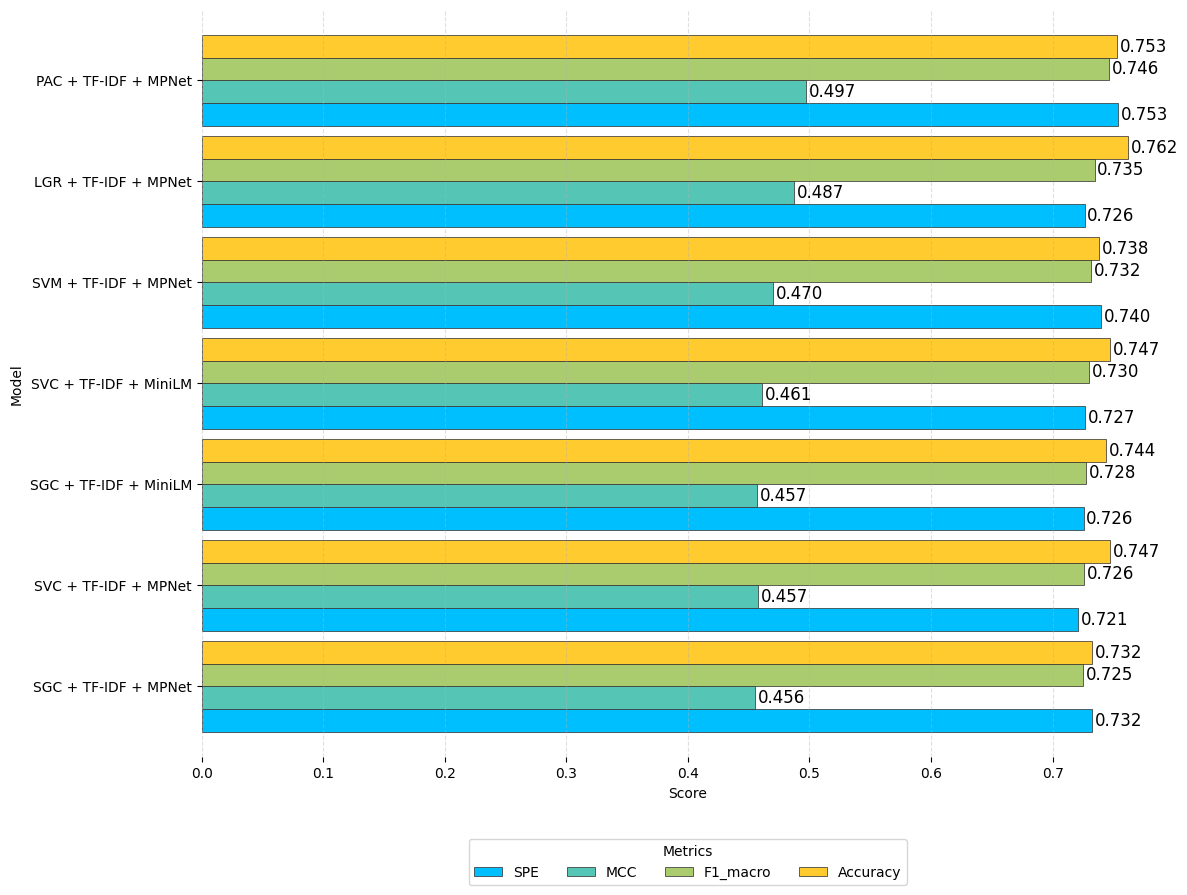

In [ ]:
df_plot = pd.concat([
    tfidf_sentence
])

df_plot=df_plot.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top5 = df_plot.sort_values('Score_mean', ascending=False).head(7)

fig, ax = plt.subplots(figsize=(12,9))
top5 = top5.sort_values('F1_macro', ascending=True)
top5[metricas].plot(
    kind='barh', ax=ax, width=0.90, color=['#00BFFF', '#55C6B5', '#AACC6E', '#FFCB2E'],
    edgecolor='#333333',linewidth=0.53
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.get_legend().remove()
ax.set_xlabel('Score')
ax.set_ylabel('Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=12)

ax.legend(
    title='Metrics',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(metricas)
)
# Remove specific borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

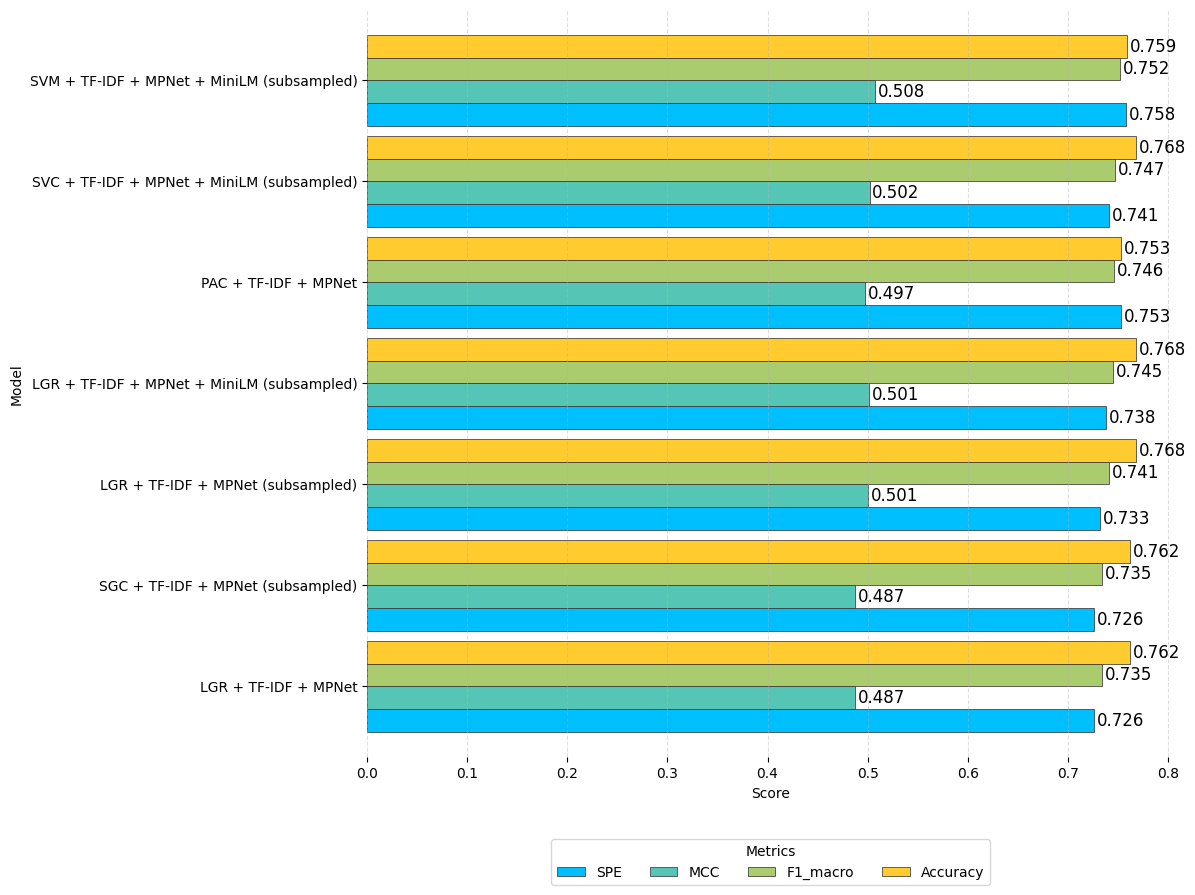

In [ ]:
df_plot = pd.concat([
    tfidf_sentence,
    tfidf_sentence_fusion_res
])

df_plot=df_plot.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top5 = df_plot.sort_values('Score_mean', ascending=False).head(7)

fig, ax = plt.subplots(figsize=(12,9))
top5 = top5.sort_values('F1_macro', ascending=True)
top5[metricas].plot(
    kind='barh', ax=ax, width=0.90, color=['#00BFFF', '#55C6B5', '#AACC6E', '#FFCB2E'],
    edgecolor='#333333',linewidth=0.53
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.get_legend().remove()
ax.set_xlabel('Score')
ax.set_ylabel('Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=12)

ax.legend(
    title='Metrics',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(metricas)
)
# Remove specific borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

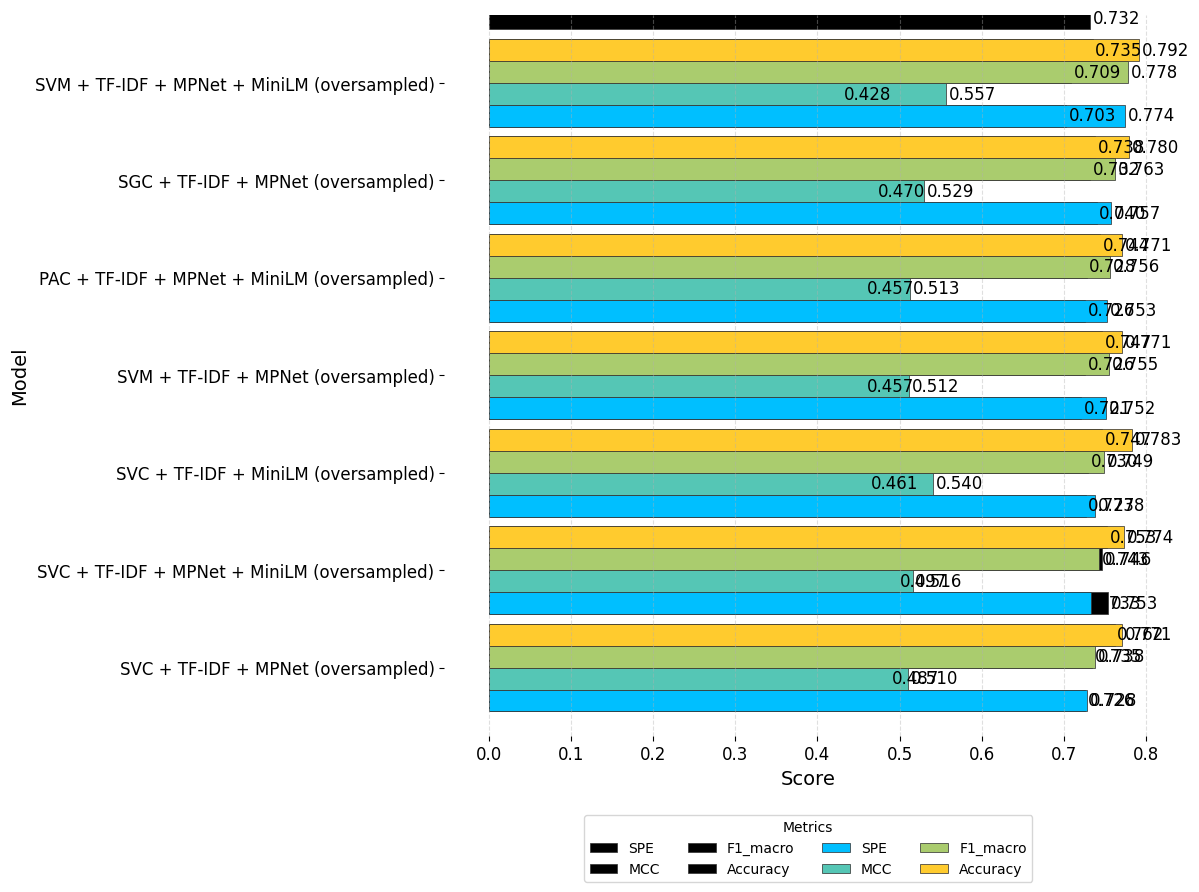

In [ ]:
df_plot = tfidf_sentence_fusion_ros

df_plot=df_plot.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top5 = df_plot.sort_values('Score_mean', ascending=False).head(7)

fig, ax = plt.subplots(figsize=(12,9))

tfidf_sentence[metricas].plot(
    kind='barh', ax=ax, width=0.90, color=['#000', '#000', '#000', '#000'],
    edgecolor='#333333',linewidth=0.53
)


top5 = top5.sort_values('F1_macro', ascending=True)
top5[metricas].plot(
    kind='barh', ax=ax, width=0.90, color=['#00BFFF', '#55C6B5', '#AACC6E', '#FFCB2E'],
    edgecolor='#333333',linewidth=0.53
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.get_legend().remove()
ax.set_xlabel('Score', fontsize=14)
ax.set_ylabel('Model', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=12)

ax.legend(
    title='Metrics',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(metricas)
)
# Remove specific borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


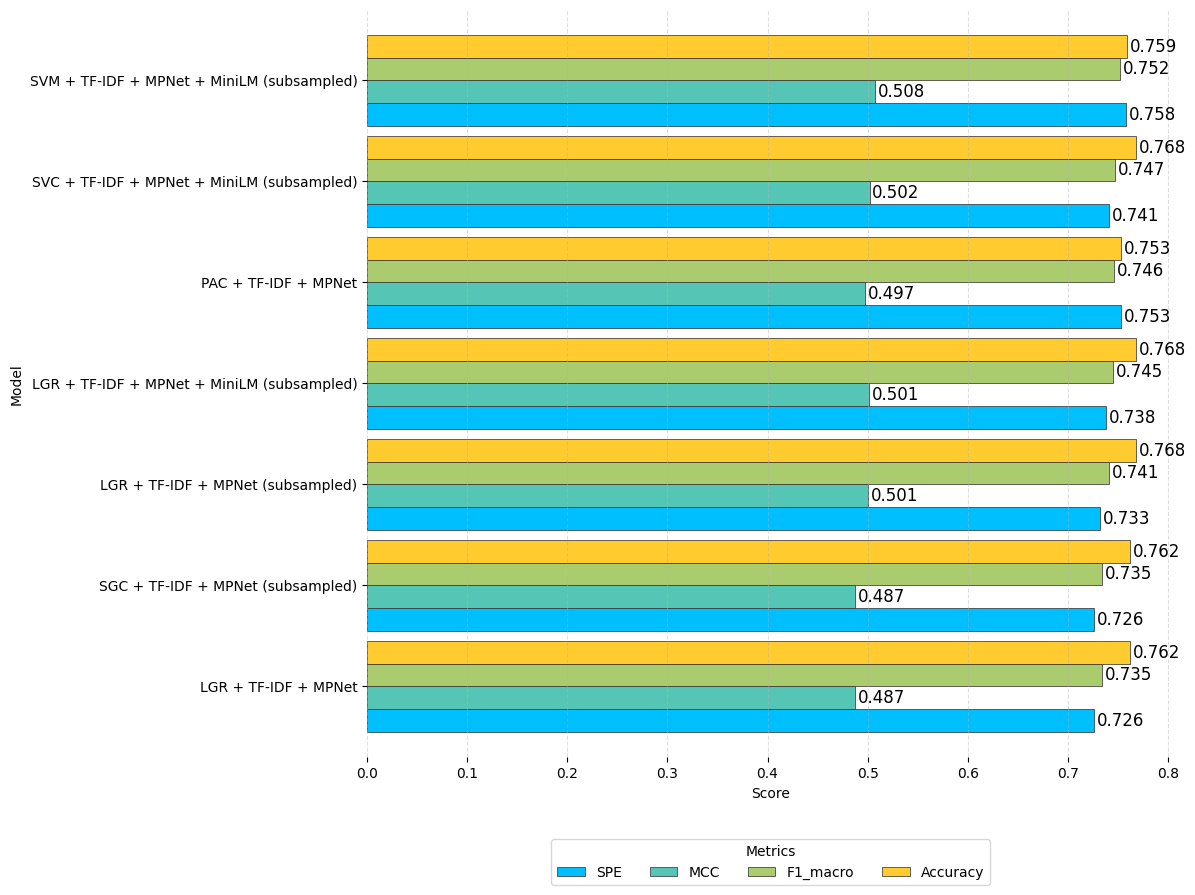

In [ ]:
df_plot = pd.concat([
    tfidf_sentence,
    tfidf_sentence_fusion_res
])

df_plot=df_plot.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top5 = df_plot.sort_values('Score_mean', ascending=False).head(7)

fig, ax = plt.subplots(figsize=(12,9))
top5 = top5.sort_values('F1_macro', ascending=True)
top5[metricas].plot(
    kind='barh', ax=ax, width=0.90, color=['#00BFFF', '#55C6B5', '#AACC6E', '#FFCB2E'],
    edgecolor='#333333',linewidth=0.53
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.get_legend().remove()
ax.set_xlabel('Score')
ax.set_ylabel('Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=12)

ax.legend(
    title='Metrics',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(metricas)
)
# Remove specific borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

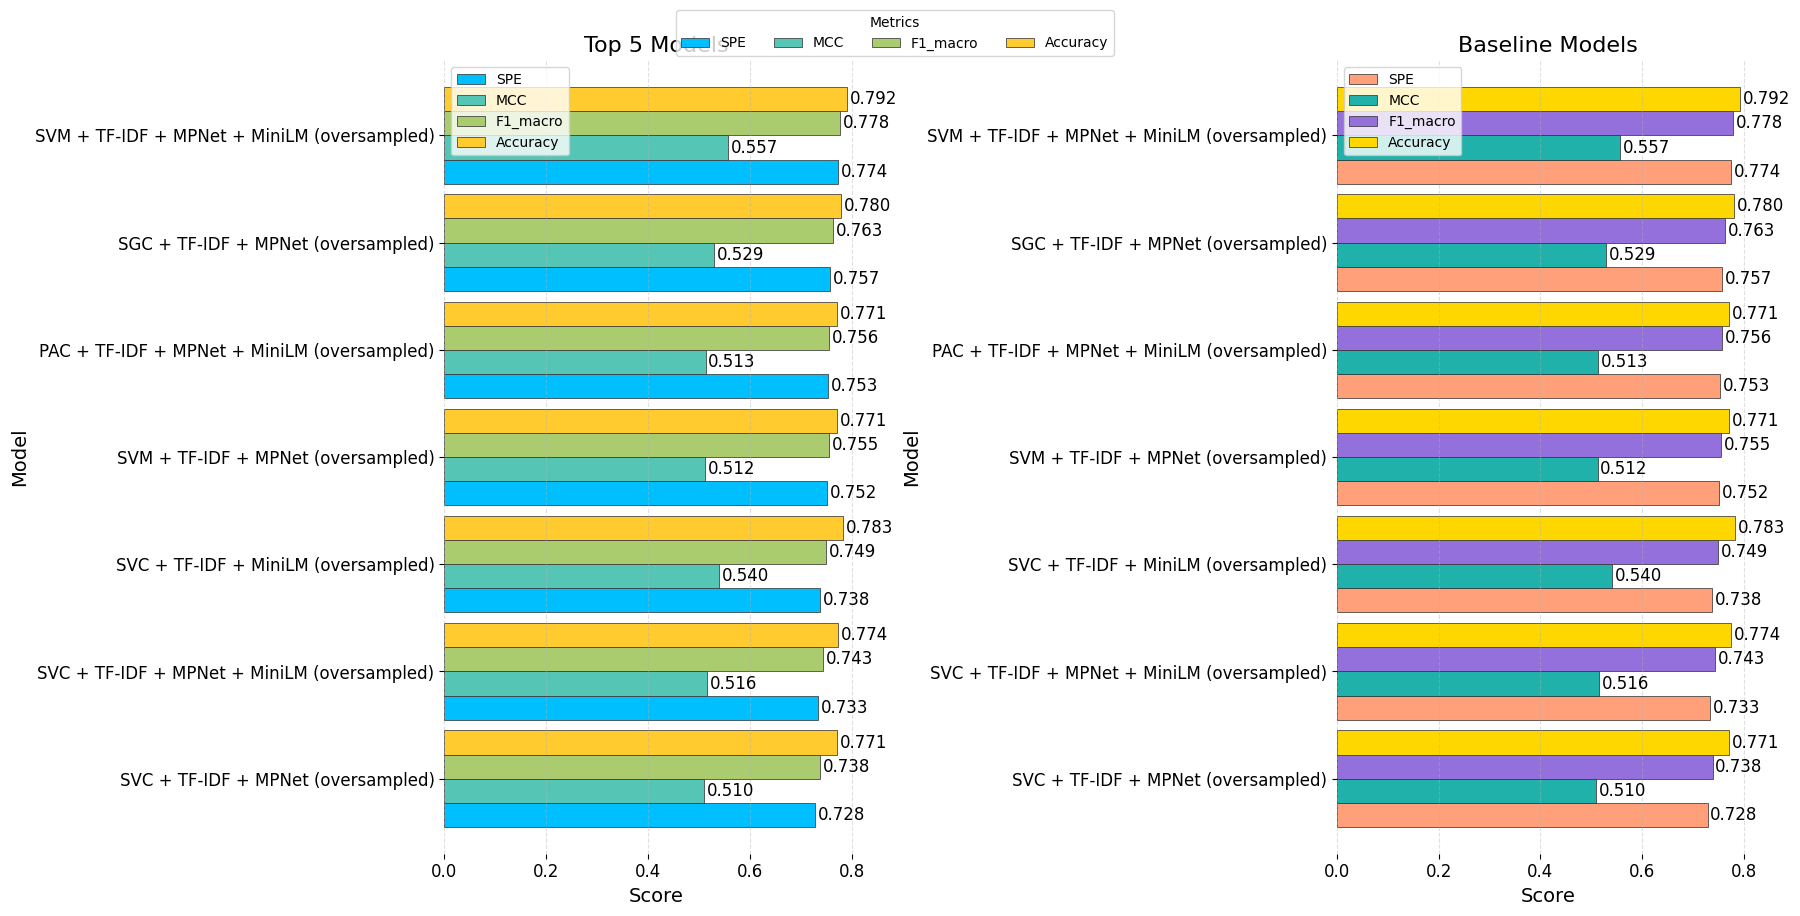

In [ ]:
# Suponiendo que tienes dos DataFrames: top5 y baseline
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,9))  # Dos subplots lado a lado


df_plot=tfidf_sentence_fusion_ros.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top51 = df_plot.sort_values('Score_mean', ascending=False).head(7)

# Primer subplot: top5 modelos
top5_sorted = top51.sort_values('F1_macro', ascending=True)
top5_sorted[metricas].plot(
    kind='barh', ax=axes[0], width=0.90, color=['#00BFFF', '#55C6B5', '#AACC6E', '#FFCB2E'],
    edgecolor='#333333', linewidth=0.53
)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].set_xlabel('Score', fontsize=14)
axes[0].set_ylabel('Model', fontsize=14)
axes[0].tick_params(axis='both', which='major', labelsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=2, fontsize=12)
axes[0].set_title('Top 5 Models', fontsize=16)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# Segundo subplot: modelos baseline

df_plot2=tfidf_sentence.set_index('Model')
metricas = ['SPE', 'MCC', 'F1_macro', 'Accuracy']
df_plot['Score_mean'] = df_plot[['Accuracy', 'F1_macro']].mean(axis=1)
top52 = df_plot.sort_values('Score_mean', ascending=False).head(7)

baseline_sorted = top52.sort_values('F1_macro', ascending=True)
baseline_sorted[metricas].plot(
    kind='barh', ax=axes[1], width=0.90, color=['#FFA07A', '#20B2AA', '#9370DB', '#FFD700'],
    edgecolor='#333333', linewidth=0.53
)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Score', fontsize=14)
axes[1].set_ylabel('Model', fontsize=14)
axes[1].tick_params(axis='both', which='major', labelsize=12)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=2, fontsize=12)
axes[1].set_title('Baseline Models', fontsize=16)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

# Leyenda común
fig.legend(
    metricas, title='Metrics',
    loc='upper center', bbox_to_anchor=(0.5, 1.02),
    ncol=len(metricas)
)

plt.tight_layout()
plt.show()